In [13]:
import pandas as pd 
import numpy as np 

from pathlib import Path

import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer                                                                                            
from sklearn.model_selection import train_test_split                                                                                                   
from sklearn.linear_model import LogisticRegression                                                                                                    
from sklearn.metrics import classification_report 

In [14]:
import sys                                                                                                                                             
sys.path.append("../src")                                                                                                                              
from utils.text_stats import top_tfidf_terms 

In [15]:
df = pd.read_csv("../data/processed/01_cleaned.csv")


In [16]:
df.head(10)

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len,month,hour,is_weekend
0,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,4282,24,12,0,0
1,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,38,28,12,0,0
2,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,1171,10,12,0,0
3,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1124,25,12,0,0
4,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,534,24,12,0,0
5,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14,0,411,21,12,0,0
6,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1375,19,12,0,0
7,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14,0,1616,10,12,0,0
8,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14,0,3039,22,12,0,0
9,entex transistion,the purpose of the email is to recap the kicko...,ham,1999-12-14,0,1734,17,12,0,0


In [17]:
df.columns

Index(['Subject', 'Message', 'Spam/Ham', 'Date', 'label', 'message_len',
       'subject_len', 'month', 'hour', 'is_weekend'],
      dtype='str')

In [18]:
df['label'] = df['label'].astype(int)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33664 entries, 0 to 33663
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Subject      33664 non-null  str  
 1   Message      33664 non-null  str  
 2   Spam/Ham     33664 non-null  str  
 3   Date         33664 non-null  str  
 4   label        33664 non-null  int64
 5   message_len  33664 non-null  int64
 6   subject_len  33664 non-null  int64
 7   month        33664 non-null  int64
 8   hour         33664 non-null  int64
 9   is_weekend   33664 non-null  int64
dtypes: int64(6), str(4)
memory usage: 2.6 MB


In [20]:
df.describe()

,label,message_len,subject_len,month,hour,is_weekend
count,33664.000000,33664.000000,33664.000000,33664.000000,33664.0,33664.000000
mean,0.510070,1631.072035,29.740762,6.305252,0.0,0.149002
std,0.499906,4210.558754,20.099648,3.338533,0.0,0.356096
min,0.000000,1.000000,1.000000,1.000000,0.0,0.000000
25%,0.000000,632.000000,18.000000,4.000000,0.0,0.000000
50%,1.000000,868.000000,25.000000,6.000000,0.0,0.000000
75%,1.000000,1674.000000,41.000000,9.000000,0.0,0.000000
max,1.000000,228353.000000,1355.000000,12.000000,0.0,1.000000


In [21]:
from utils.text_stats import top_tfidf_terms

In [22]:
spam_texts = df[df['label']==1]['Message']
ham_texts = df[df['label']==0]['Message']

print("Spam size:", len(spam_texts))
print("Ham size:", len(ham_texts))

Spam size: 17171
Ham size: 16493


In [23]:
spam_terms = top_tfidf_terms(df[df['label']==1]['Message'], n=30, stop_words='english')
ham_terms = top_tfidf_terms(df[df['label']==0]['Message'], n=30, stop_words='english')
print(spam_terms)
print(ham_terms)


[(np.float64(0.10816061724141302), 'ivanhoe'), (np.float64(0.10816061724141302), '07'), (np.float64(0.08245727616944779), 'cost'), (np.float64(0.08060965971846416), 'type'), (np.float64(0.08060965971846416), 'schedule'), (np.float64(0.08060965971846416), 'final'), (np.float64(0.07210707816093591), 'fred'), (np.float64(0.07062222488745756), 'enron'), (np.float64(0.06593451872256524), '2002'), (np.float64(0.06268021972429454), 'subject'), (np.float64(0.054528194208823), 'point'), (np.float64(0.05408030862070651), 'jordan'), (np.float64(0.05373977314564472), 'trans'), (np.float64(0.05373977314564472), 'schedules'), (np.float64(0.05373977314564472), 'id'), (np.float64(0.05373977314564472), 'date'), (np.float64(0.05373977314564472), '02'), (np.float64(0.053674702874664325), 'ubs'), (np.float64(0.050353377438088626), 'transfers'), (np.float64(0.050353377438088626), 'center'), (np.float64(0.04800389069931113), '2001'), (np.float64(0.046593987863477675), 'don'), (np.float64(0.04488486530728601

- Distribution features

In [24]:
df['word_count'] = df['Message'].str.split().str.len()
df['num_caps'] = df["Message"].str.count(r"[A-Z]")
df['num_digits'] = df["Message"].str.count(r"\d")
df["num_urls"] = df["Message"].str.count(r"https?://\S+")

In [25]:
df.head(10)

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len,month,hour,is_weekend,word_count,num_caps,num_digits,num_urls
0,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,4282,24,12,0,0,1572,0,315,0
1,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,38,28,12,0,0,8,0,1,0
2,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,1171,10,12,0,0,344,0,68,0
3,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1124,25,12,0,0,318,0,55,0
4,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,534,24,12,0,0,119,0,19,0
5,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14,0,411,21,12,0,0,90,0,76,0
6,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1375,19,12,0,0,340,0,146,0
7,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14,0,1616,10,12,0,0,328,0,45,0
8,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14,0,3039,22,12,0,0,640,0,28,0
9,entex transistion,the purpose of the email is to recap the kicko...,ham,1999-12-14,0,1734,17,12,0,0,329,0,14,0


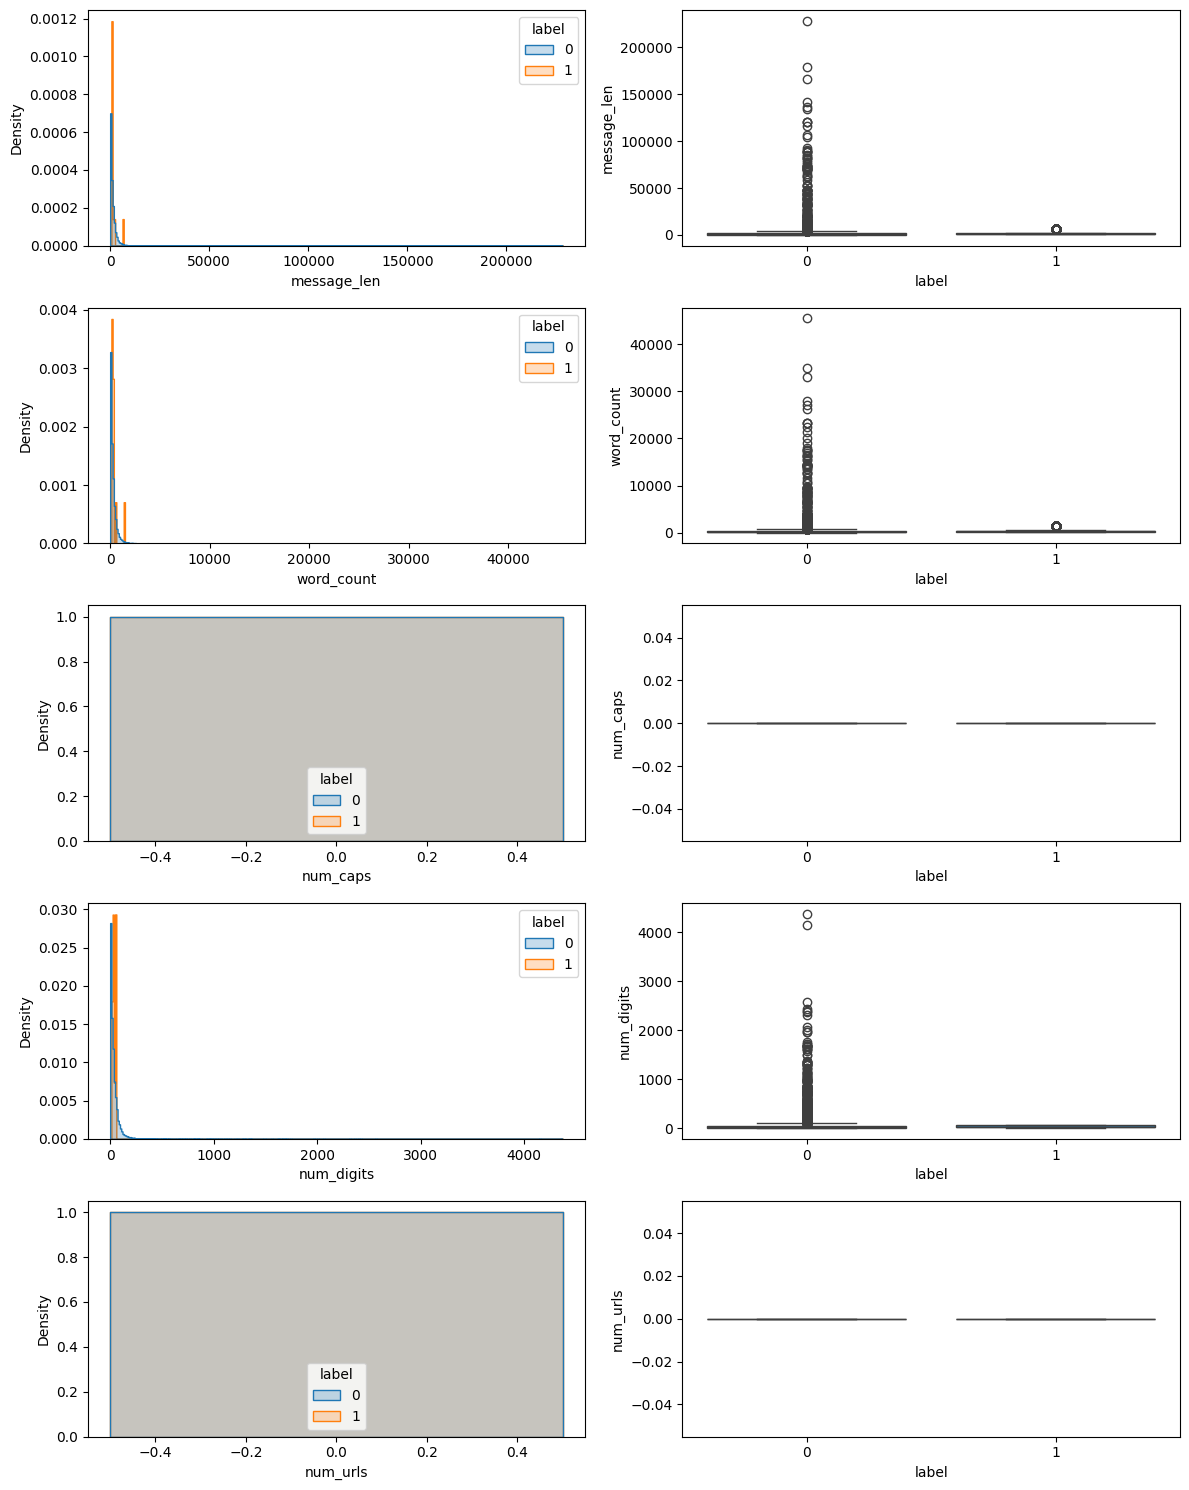

In [26]:
long_features = ["message_len", "word_count", "num_caps", "num_digits", "num_urls"]
fig, axes = plt.subplots(len(long_features), 2, figsize=(12, 3 * len(long_features)))
for i, feat in enumerate(long_features):                                                                                                               
      sns.histplot(data=df, x=feat, hue="label", element="step", stat="density", common_norm=False, ax=axes[i, 0])                                       
      sns.boxplot(data=df, x="label", y=feat, ax=axes[i, 1])                                                                                             
plt.tight_layout()

- Class balance

C:\Users\minhp\AppData\Local\Temp\ipykernel_15136\2992141892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = label_counts.index, y= label_counts.values, palette="Set2")


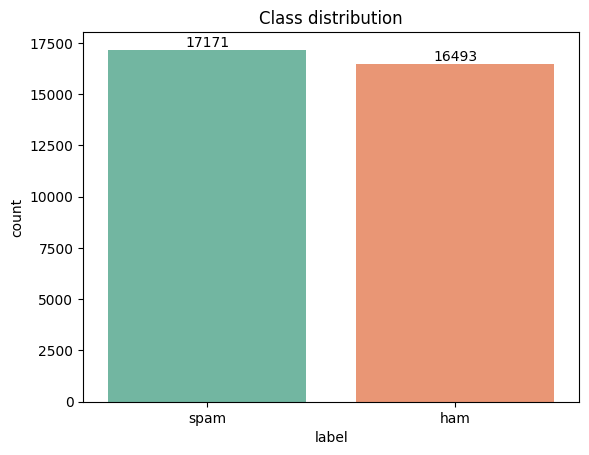

In [27]:
label_counts = df["label"].value_counts().rename({0: "ham", 1: "spam"})
sns.barplot(x = label_counts.index, y= label_counts.values, palette="Set2")
plt.title("Class distribution")
plt.ylabel('count')
for idx, val in enumerate(label_counts.values):
  plt.text(idx, val, f"{val}", ha="center", va="bottom")

n-gram TF‑IDF (bi/tri)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

def top_terms(texts, ngram=(1, 2), n=20):                                                                                                              
    vect = TfidfVectorizer(ngram_range=ngram, stop_words="english")                                                                                    
    tfidf = vect.fit_transform(texts)                                                                                                                  
    means = tfidf.mean(axis=0).A1                                                                                                                      
    idx = means.argsort()[::-1][:n]                                                                                                                    
    vocab = np.array(vect.get_feature_names_out())                                                                                                     
    return pd.DataFrame({"term": vocab[idx], "tfidf": means[idx]})

In [29]:
spam_bi_tri = top_terms(df.loc[df["label"] == 1, "Message"], ngram=(2, 3))
ham_bi_tri = top_terms(df.loc[df["label"] == 0, "Message"], ngram=(2, 3))
display(spam_bi_tri, ham_bi_tri)

,term,tfidf
0,07 2002,0.066651
1,subject ivanhoe,0.049988
2,date 02,0.044780
3,cost center,0.036660
4,original message,0.033902
5,07 2002 07,0.033325
6,2002 07,0.033325
7,jordan et,0.033325
8,fred jordan et,0.033325
9,frazier perry,0.033325


,term,tfidf
0,hou ect,0.012851
1,ect ect,0.012557
2,hou ect ect,0.011059
3,let know,0.005462
4,enron com,0.005203
5,enron enron,0.005147
6,vince kaminski,0.004827
7,original message,0.004345
8,cc subject,0.004276
9,start date,0.004099


- Visualize term frequencies / word clouds

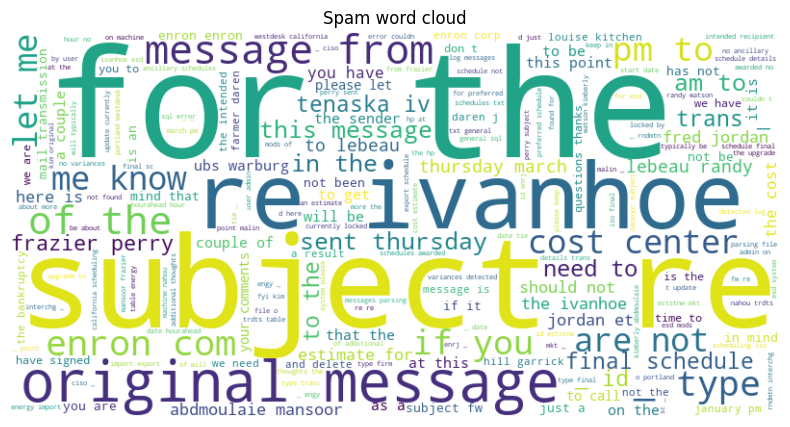

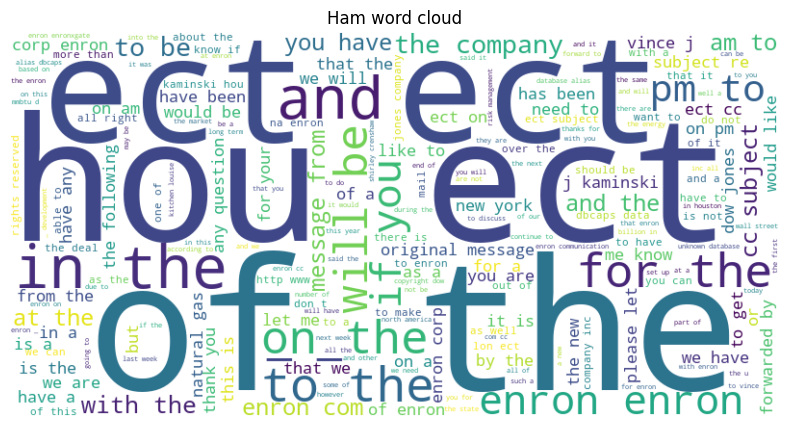

In [30]:
from wordcloud import WordCloud

def plot_wordcloud(texts, title):                                                                                                                      
    wc = WordCloud(width=800, height=400, background_color="white", stopwords="english").generate(" ".join(texts))                                     
    plt.figure(figsize=(10, 5))                                                                                                                        
    plt.imshow(wc, interpolation="bilinear")                                                                                                           
    plt.axis("off")                                                                                                                                    
    plt.title(title)                                                                                                                                   
                                                                                                                                                         
plot_wordcloud(df.loc[df["label"] == 1, "Message"], "Spam word cloud")                                                                                 
plot_wordcloud(df.loc[df["label"] == 0, "Message"], "Ham word cloud")

Text(0.5, 1.0, 'Feature correlations')

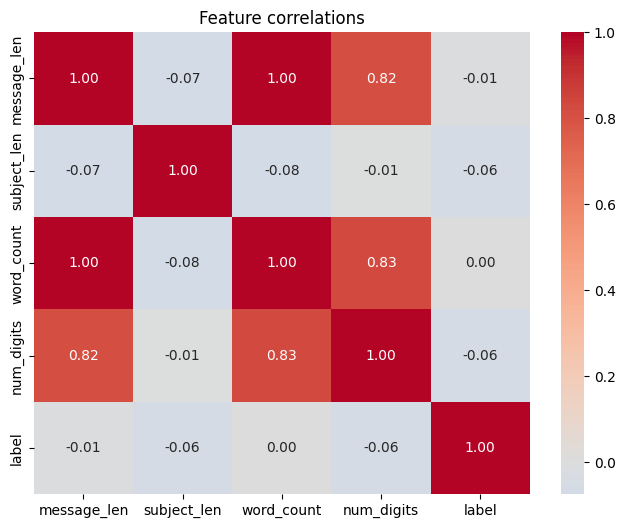

In [31]:
num_cols = ["message_len", "subject_len", "word_count", "num_digits"]    
corr = df[num_cols + ["label"]].corr()                                                                                                                 
plt.figure(figsize=(8, 6))                                                                                                                             
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)                                                                                    
plt.title("Feature correlations")   

In [32]:
df.head(10)

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len,month,hour,is_weekend,word_count,num_caps,num_digits,num_urls
0,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,4282,24,12,0,0,1572,0,315,0
1,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,38,28,12,0,0,8,0,1,0
2,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,1171,10,12,0,0,344,0,68,0
3,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1124,25,12,0,0,318,0,55,0
4,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,534,24,12,0,0,119,0,19,0
5,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14,0,411,21,12,0,0,90,0,76,0
6,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1375,19,12,0,0,340,0,146,0
7,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14,0,1616,10,12,0,0,328,0,45,0
8,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14,0,3039,22,12,0,0,640,0,28,0
9,entex transistion,the purpose of the email is to recap the kicko...,ham,1999-12-14,0,1734,17,12,0,0,329,0,14,0


In [33]:
df.columns

Index(['Subject', 'Message', 'Spam/Ham', 'Date', 'label', 'message_len',
       'subject_len', 'month', 'hour', 'is_weekend', 'word_count', 'num_caps',
       'num_digits', 'num_urls'],
      dtype='str')

In [34]:
df.to_csv("../data/processed/02_basic_features.csv", index=False)
